# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import tree
import warnings

warnings.filterwarnings('ignore')
pd.options.display.max_rows = 10

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv('../data/am_pm.csv', index_col='date')
df

,am,pm,target,predict
date,,,,
2020-04-17,21,2,0,1
2020-04-18,1,68,1,0
2020-04-19,18,15,1,0
2020-04-20,2,23,0,0
2020-04-21,0,25,0,0
...,...,...,...,...
2020-05-17,2,46,1,0
2020-05-18,0,3,0,0
2020-05-19,20,14,0,0


In [3]:
X_train = df[['am', 'pm']]
y_train = df['target']

log_reg = LogisticRegression(random_state=21, fit_intercept=False)
log_reg.fit(X_train, y_train)
predict_col = log_reg.predict(X_train)
df['predict'] = predict_col
acc = accuracy_score(predict_col, y_train)
acc

0.6285714285714286

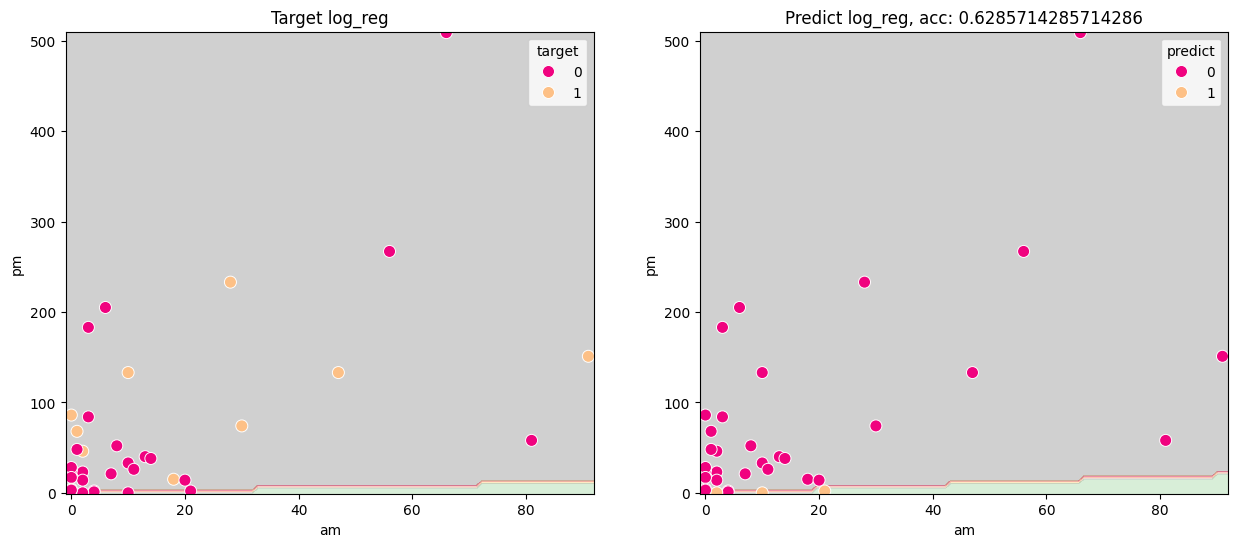

In [4]:
def plot_des(X, model, acc, title):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    x_min, x_max = X['am'].min() - 1, X['am'].max() + 1
    y_min, y_max = X['pm'].min() - 1, X['pm'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

 

    for num, hue in enumerate(['target', 'predict']):
        model.fit(X, df[hue])
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax[num].contourf(xx, yy, Z, alpha=0.3, cmap='Accent_r')
        sns.scatterplot(data=df, x='am', y='pm', hue=hue, palette='Accent_r', ax=ax[num], s=75)
        ax[num].set_title(f'Predict {title}, acc: {acc}')  if hue == 'predict' else ax[num].set_title(f'Target {title}')
        ax[num].set_xlabel('am')
        ax[num].set_ylabel('pm')

plot_des(X=X_train, model=log_reg, acc=acc, title='log_reg')

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [5]:
scaler = StandardScaler()
# fit and transform the data != fit_transform
scaled_data = scaler.fit(X_train)
scaled_data = scaled_data.transform(X_train)
df[['am', 'pm']] = scaled_data
X_train = df[['am', 'pm']]

log_reg_scaled = LogisticRegression(random_state=21, fit_intercept=False)
log_reg_scaled.fit(X_train, y_train)
predict_col = log_reg_scaled.predict(X_train)
df['predict'] = predict_col
acc = accuracy_score(predict_col, y_train)
acc

0.7428571428571429

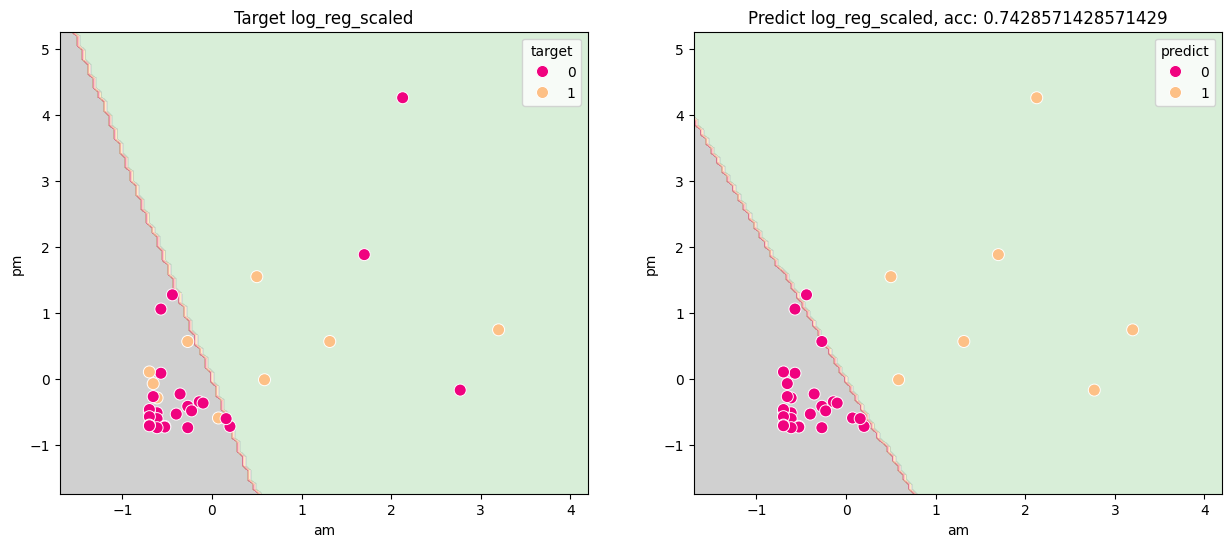

In [6]:
plot_des(X=X_train, model=log_reg_scaled, acc=acc, title='log_reg_scaled')

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [7]:
for name in ['linear', 'sigmoid', 'poly', 'rbf']:
    svc = SVC(random_state=21, probability=True, kernel=name)
    svc.fit(X_train, y_train)
    predict_col = svc.predict(X_train)
    df['predict'] = predict_col
    acc = accuracy_score(predict_col, y_train)
    print(acc, name)

0.7142857142857143 linear
0.6857142857142857 sigmoid
0.7428571428571429 poly
0.7428571428571429 rbf


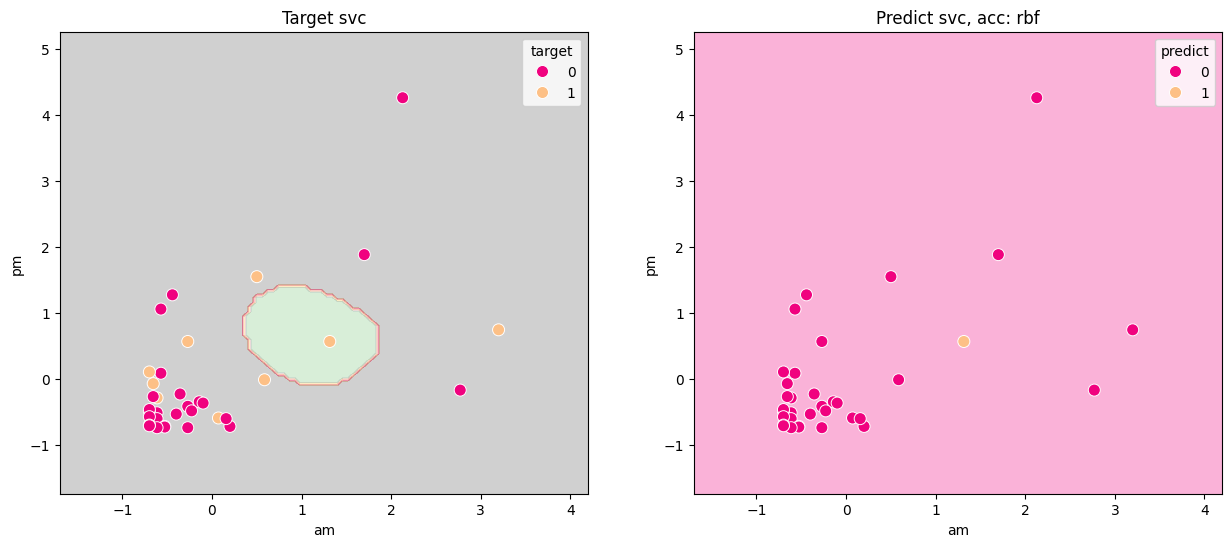

In [8]:
plot_des(X=X_train, model=svc, acc='rbf', title='svc')

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [9]:
for x in range(1, 5):
    dec_tree_class = tree.DecisionTreeClassifier(random_state=42, max_depth=x).fit(X_train.values, y_train.values)
    predict = dec_tree_class.predict(X_train.values)
    df['predict'] = predict_col
    acc = accuracy_score(predict, y_train)
    print(acc, '-', f'depth={x}')

0.7714285714285715 - depth=1
0.8571428571428571 - depth=2
0.8857142857142857 - depth=3
0.9428571428571428 - depth=4


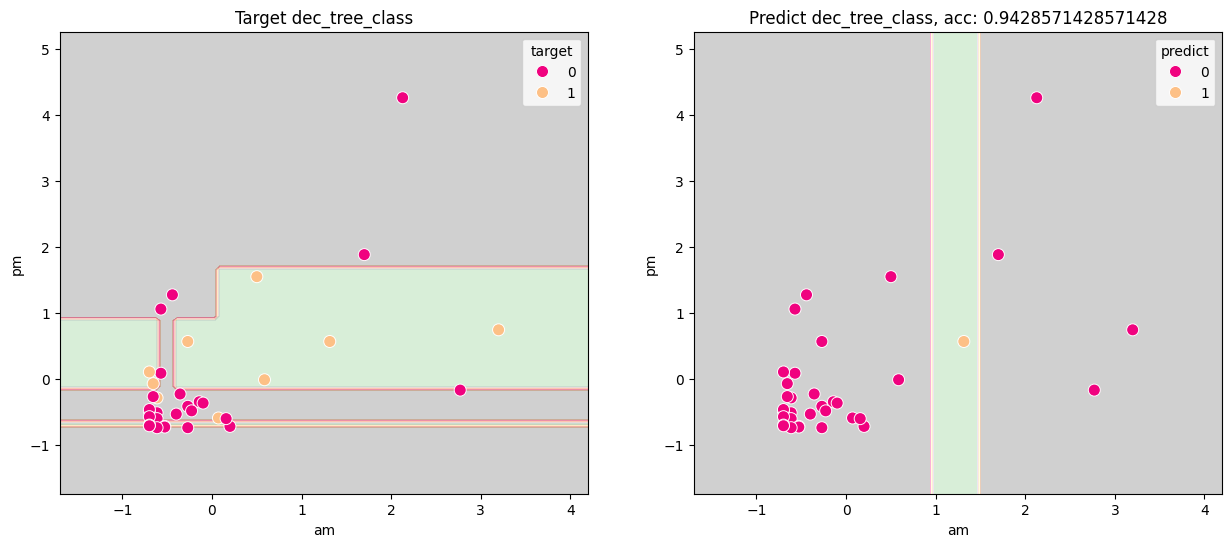

In [10]:
plot_des(X=X_train, model=dec_tree_class, acc=acc, title='dec_tree_class')

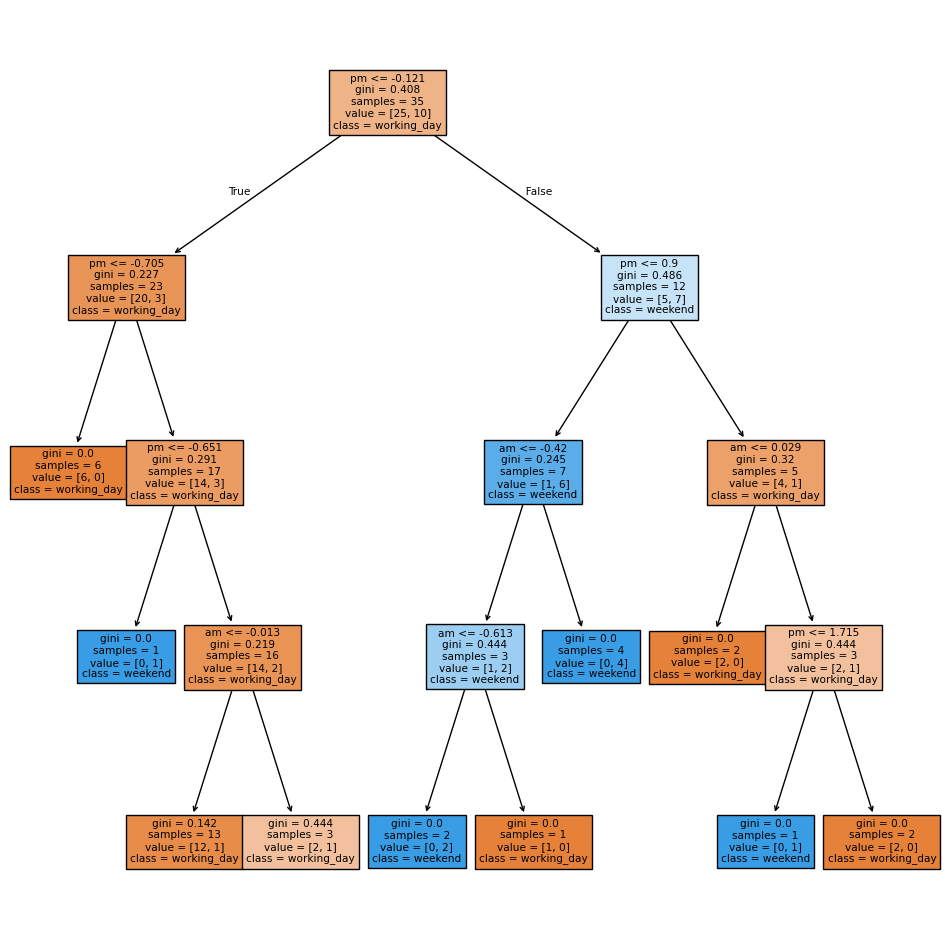

In [11]:
plt.figure(figsize=(12,12))
# invoking plot_des swap model fitting from target to predict in order to plot decision boundary, fit model to target once again below
dec_tree_class = tree.DecisionTreeClassifier(random_state=42, max_depth=4).fit(X_train.values, y_train.values)
ax = tree.plot_tree(dec_tree_class, filled=True, feature_names=['am', 'pm'], class_names=['working_day', 'weekend'])
plt.show()
# counts only bright cells where gini = 0

How many leaves in the visualized tree label days as working days?  
Answer: 4